# 04 — RFM Customer Segmentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/cleaned_data.csv')
print("Unique customers:", df['Customer ID'].nunique())


Unique customers: 9000


## Build RFM Table

In [2]:
# No date column — use Order ID number as recency proxy
rfm = df.groupby('Customer ID').agg(
    Frequency  = ('Order ID', 'count'),
    Monetary   = ('Order Value (INR)', 'sum'),
    Last_Order = ('Order ID', 'last')
).reset_index()

rfm['Order_Num'] = rfm['Last_Order'].str.extract(r'(\d+)').astype(int)
rfm['Recency']   = rfm['Order_Num'].max() - rfm['Order_Num']

print(rfm[['Customer ID','Recency','Frequency','Monetary']].describe().round(1))


       Recency  Frequency  Monetary
count   9000.0     9000.0    9000.0
mean    9064.4       11.1    6566.6
std     9066.6        3.3    2388.8
min        0.0        2.0     671.0
25%     2636.8        9.0    4840.0
50%     6334.0       11.0    6378.0
75%    12431.0       13.0    8152.0
max    73039.0       26.0   16255.0


## Score & Segment

In [3]:
rfm['R'] = pd.qcut(rfm['Recency'],                          q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'),   q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'].rank(method='first'),    q=5, labels=[1,2,3,4,5]).astype(int)

def segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:     return 'Champions'
    elif r >= 3 and f >= 3:              return 'Loyal'
    elif r >= 4 and f <= 2:              return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 3:   return 'Potential Loyalists'
    elif r <= 2 and f >= 3:              return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:   return 'Hibernating'
    elif r == 1 and f == 1:              return 'Lost'
    else:                                return 'Promising'

rfm['Segment'] = rfm.apply(segment, axis=1)

print(rfm['Segment'].value_counts())


Segment
Loyal                  2237
At Risk                1789
Promising              1386
Champions              1374
New Customers          1089
Lost                    583
Hibernating             386
Potential Loyalists     156
Name: count, dtype: int64


## Segment Analysis & Visualisation

In [4]:
seg_profile = rfm.groupby('Segment').agg(
    Customers     = ('Customer ID', 'count'),
    Avg_Frequency = ('Frequency',   'mean'),
    Avg_Monetary  = ('Monetary',    'mean'),
    Total_Revenue = ('Monetary',    'sum')
).round(2)

seg_profile['Revenue_Share'] = (seg_profile['Total_Revenue'] / seg_profile['Total_Revenue'].sum() * 100).round(1)
print(seg_profile.sort_values('Total_Revenue', ascending=False))


                     Customers  Avg_Frequency  Avg_Monetary  Total_Revenue  \
Segment                                                                      
Loyal                     2237          12.48       7115.92       15918318   
At Risk                   1789          12.76       7549.74       13506479   
Champions                 1374          15.00       9283.85       12756010   
Promising                 1386           7.97       4260.41        5904928   
New Customers             1089           8.27       4850.48        5282170   
Hibernating                386           8.98       6663.65        2572170   
Lost                       583           6.28       3592.87        2094644   
Potential Loyalists        156           9.39       6825.13        1064721   

                     Revenue_Share  
Segment                             
Loyal                         26.9  
At Risk                       22.9  
Champions                     21.6  
Promising                     10.0

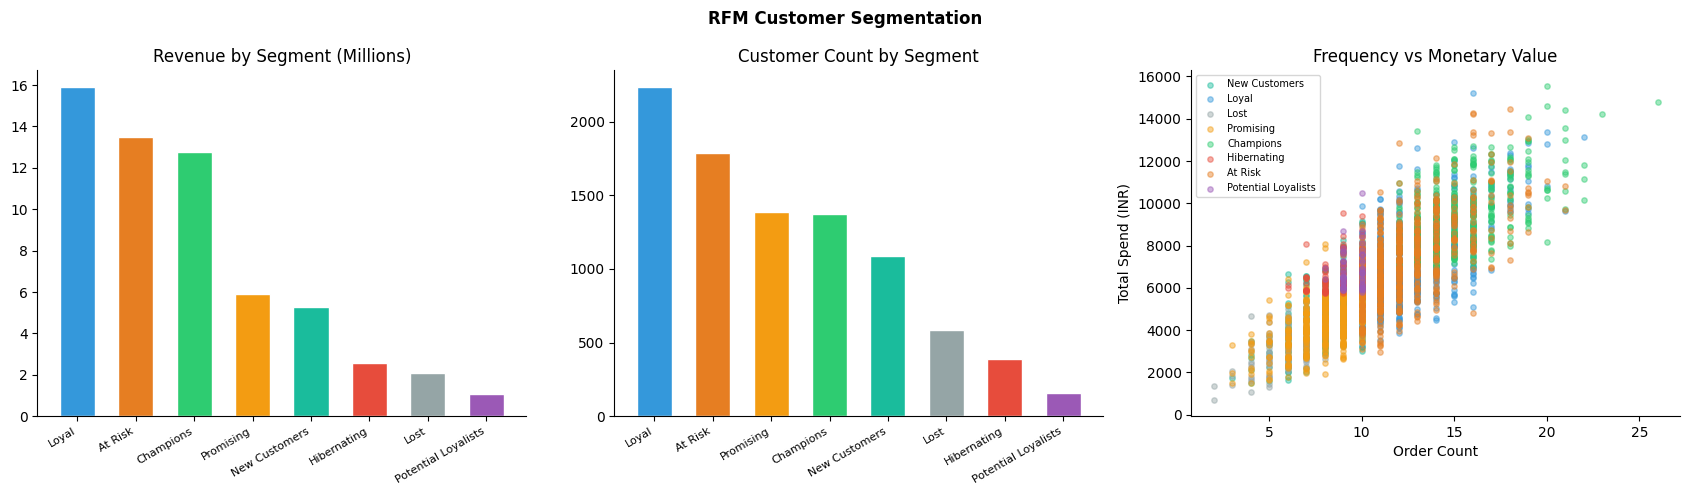

In [5]:
SEG_COL = {
    'Champions':'#2ECC71', 'Loyal':'#3498DB',
    'Potential Loyalists':'#9B59B6', 'New Customers':'#1ABC9C',
    'At Risk':'#E67E22', 'Hibernating':'#E74C3C',
    'Lost':'#95A5A6', 'Promising':'#F39C12'
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('RFM Customer Segmentation', fontweight='bold')

rev_sorted = seg_profile['Total_Revenue'].sort_values(ascending=False)
colors1    = [SEG_COL.get(s, '#BDC3C7') for s in rev_sorted.index]
axes[0].bar(range(len(rev_sorted)), rev_sorted.values/1e6, color=colors1, edgecolor='white', width=0.6)
axes[0].set_title('Revenue by Segment (Millions)')
axes[0].set_xticks(range(len(rev_sorted)))
axes[0].set_xticklabels(rev_sorted.index, rotation=30, ha='right', fontsize=8)

cnt_sorted = seg_profile['Customers'].sort_values(ascending=False)
colors2    = [SEG_COL.get(s, '#BDC3C7') for s in cnt_sorted.index]
axes[1].bar(range(len(cnt_sorted)), cnt_sorted.values, color=colors2, edgecolor='white', width=0.6)
axes[1].set_title('Customer Count by Segment')
axes[1].set_xticks(range(len(cnt_sorted)))
axes[1].set_xticklabels(cnt_sorted.index, rotation=30, ha='right', fontsize=8)

sample = rfm.sample(min(3000, len(rfm)), random_state=42)
for seg in sample['Segment'].unique():
    sub = sample[sample['Segment'] == seg]
    axes[2].scatter(sub['Frequency'], sub['Monetary'],
                    label=seg, alpha=0.45, s=15, color=SEG_COL.get(seg, '#BDC3C7'))
axes[2].set_title('Frequency vs Monetary Value')
axes[2].set_xlabel('Order Count')
axes[2].set_ylabel('Total Spend (INR)')
axes[2].legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig('../visuals/10_rfm.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
print("=== Segment Action Matrix ===\n")
actions = {
    'Champions'           : 'Reward & retain. Ask for reviews. Early access to offers.',
    'Loyal'               : 'Upgrade to loyalty tier. Cross-sell premium categories.',
    'Potential Loyalists' : 'Membership offer. Personalised recommendations.',
    'New Customers'       : 'Strong onboarding. Priority delivery for first 3 orders.',
    'Promising'           : 'Bundle deals to increase order frequency.',
    'At Risk'             : 'Win-back campaign. Diagnose failed orders. Offer discount.',
    'Hibernating'         : 'Time-limited coupon. Push notification.',
    'Lost'                : 'Survey why they left. Low-cost reactivation attempt.'
}
for seg, action in actions.items():
    cnt = rfm[rfm['Segment'] == seg].shape[0]
    rev = rfm[rfm['Segment'] == seg]['Monetary'].sum()
    print(seg, '|', cnt, 'customers | Rs', round(rev/1e6,1), 'M')
    print(' ->', action, '\n')


=== Segment Action Matrix ===

Champions | 1374 customers | Rs 12.8 M
 -> Reward & retain. Ask for reviews. Early access to offers. 

Loyal | 2237 customers | Rs 15.9 M
 -> Upgrade to loyalty tier. Cross-sell premium categories. 

Potential Loyalists | 156 customers | Rs 1.1 M
 -> Membership offer. Personalised recommendations. 

New Customers | 1089 customers | Rs 5.3 M
 -> Strong onboarding. Priority delivery for first 3 orders. 

Promising | 1386 customers | Rs 5.9 M
 -> Bundle deals to increase order frequency. 

At Risk | 1789 customers | Rs 13.5 M
 -> Win-back campaign. Diagnose failed orders. Offer discount. 

Hibernating | 386 customers | Rs 2.6 M
 -> Time-limited coupon. Push notification. 

Lost | 583 customers | Rs 2.1 M
 -> Survey why they left. Low-cost reactivation attempt. 



In [7]:
rfm.to_csv('../data/rfm_segments.csv', index=False)
print("Saved rfm_segments.csv")


Saved rfm_segments.csv
